## Step 1 資料載入及清理 (Data Ingestion & Cleaning)

以下各步驟使用Google Gemini為主，協助開發程式，係因Windsurf免費用量用罄。

1. 讀取水利署河川面 Shapefile → 檢查 CRS（應為 EPSG:3826）
2. 讀取消防署避難所 CSV → 轉為 GeoDataFrame → 轉換至 **EPSG:3826**
3. **資料清理**：過濾座標為 0 或超出台灣範圍的記錄，記錄清理前後的筆數差異
4. 讀取鄉鎮界 → 轉換至 **EPSG:3826**

因SSL憑證問題，全部改為檔案下載至本機後直接讀取。

註：Shelter檔案係直接提取Week2作業成果，直接引入data故以下無需進行清理，已複製清理用之shelter_data_analysis.py及其清理後csv檔案存於output已供參考。

In [4]:
import pandas as pd
import geopandas as gpd
import os

print("=" * 60)
print("STEP 1: DATA LOADING, CLEANING & CRS STANDARDIZATION")
print("=" * 60)

# ---------------------------------------------------------
# 1. 水利署河川面 Shapefile (本機路徑)
# ---------------------------------------------------------
print("讀取本機水利署河川資料中...")
river_path = r"C:\QGIS2\Week3_work\data\RIVERPOLY\riverpoly.shp"

if os.path.exists(river_path):
    rivers = gpd.read_file(river_path)
    
    # 檢查 CRS，若非 EPSG:3826 則轉換
    if rivers.crs != 'EPSG:3826':
        rivers = rivers.to_crs(epsg=3826)
        
    print(f"✓ 河川資料讀取完成，共 {len(rivers)} 筆圖徵。目前 CRS: {rivers.crs}")
else:
    print(f"❌ 找不到河川檔案，請確認路徑: {river_path}")


# ---------------------------------------------------------
# 2. 消防署避難所 CSV
# ---------------------------------------------------------
print("\n讀取並清理避難所 CSV 資料...")
csv_path = r'C:\QGIS2\Week3_work\data\shelter_data_cleaned.csv'
df_shelters = pd.read_csv(csv_path)

# 將 DataFrame 轉為 GeoDataFrame (原始宣告為經緯度 EPSG:4326)
shelters_gdf = gpd.GeoDataFrame(
    df_shelters,
    geometry=gpd.points_from_xy(df_shelters['經度'], df_shelters['緯度']),
    crs='EPSG:4326'
)

# 轉換至 EPSG:3826
shelters_3826 = shelters_gdf.to_crs(epsg=3826)

print(f"✓ 避難所資料轉換完成，共 {len(shelters_3826)} 筆有效點位。目前 CRS: {shelters_3826.crs}")
#print(shelters_3826.head()) 用以檢驗讀取正確與否

# ---------------------------------------------------------
# 3. 鄉鎮界 Shapefile (本機路徑)
# ---------------------------------------------------------
print("\n讀取鄉鎮界資料...")
township_path = r"C:\QGIS2\Week3_work\data\鄉(鎮、市、區)界線1140318\TOWN_MOI_1140318.shp"

if os.path.exists(township_path):
    townships = gpd.read_file(township_path)
    
    # 檢查 CRS，若非 EPSG:3826 則轉換
    if townships.crs != 'EPSG:3826':
        townships = townships.to_crs(epsg=3826)
        
    print(f"✓ 鄉鎮界資料讀取完成，共 {len(townships)} 筆行政區。目前 CRS: {townships.crs}")
else:
    print(f"❌ 找不到鄉鎮界檔案，請確認路徑: {township_path}")

print("\n" + "=" * 60)
print("第一階段資料準備完畢！所有圖層皆已統一至 EPSG:3826")

STEP 1: DATA LOADING, CLEANING & CRS STANDARDIZATION
讀取本機水利署河川資料中...
✓ 河川資料讀取完成，共 13262 筆圖徵。目前 CRS: EPSG:3826

讀取並清理避難所 CSV 資料...
✓ 避難所資料轉換完成，共 5048 筆有效點位。目前 CRS: EPSG:3826

讀取鄉鎮界資料...
✓ 鄉鎮界資料讀取完成，共 368 筆行政區。目前 CRS: EPSG:3826

第一階段資料準備完畢！所有圖層皆已統一至 EPSG:3826


## Step 2 多級緩衝區分析 (Multi-Buffer Risk Zoning)

1. **三級河川警戒緩衝區**：
   - 從 `.env` 讀取參數：`BUFFER_HIGH=500`、`BUFFER_MED=1000`、`BUFFER_LOW=2000`（單位：公尺）
   - 建立三層緩衝區：**高風險（500m）/ 中風險（1km）/ 低風險（2km）**
   - 必須在 EPSG:3826 下做 buffer（Lab 1 的教訓）

2. **空間連接 (Spatial Join)**：
   - `gpd.sjoin()` 找出各級緩衝區內的避難所
   - 標記每個避難所的風險等級：高 / 中 / 低 / 安全
   - 處理一對多問題：若一個避難所同時落在多個緩衝區，取最高風險等級
   註：以sort先排序風險等級(高到低)，再清除重複出現之避難所id(保留第一筆)

In [5]:
#三級河川緩衝區建立

import os
import pandas as pd
import geopandas as gpd
from dotenv import load_dotenv

print("=" * 60)
print("STEP 2: CREATE MULTI-LEVEL RIVER BUFFERS (EPSG:3826)")
print("=" * 60)

# 1. 載入 .env 檔案中的環境變數
load_dotenv()

# 取得緩衝區參數，若 .env 沒設定則給定預設值
buf_high = int(os.getenv('BUFFER_HIGH', 500))
buf_med = int(os.getenv('BUFFER_MED', 1000))
buf_low = int(os.getenv('BUFFER_LOW', 2000))

print(f"讀取緩衝區參數: 高風險={buf_high}m, 中風險={buf_med}m, 低風險={buf_low}m")

# 2. 建立三級緩衝區 (確認在 EPSG:3826 下進行)
print("產生緩衝區多邊形中...")

# 高風險區 (High)
buffer_high = gpd.GeoDataFrame(
    {'risk_level': ['High'] * len(rivers)},
    geometry=rivers.buffer(buf_high),
    crs='EPSG:3826'
)

# 中風險區 (Medium)
buffer_med = gpd.GeoDataFrame(
    {'risk_level': ['Medium'] * len(rivers)},
    geometry=rivers.buffer(buf_med),
    crs='EPSG:3826'
)

# 低風險區 (Low)
buffer_low = gpd.GeoDataFrame(
    {'risk_level': ['Low'] * len(rivers)},
    geometry=rivers.buffer(buf_low),
    crs='EPSG:3826'
)

# 3. 將三個等級的緩衝區合併成一個 GeoDataFrame，方便後續一次性做空間連接
all_risk_buffers = pd.concat([buffer_high, buffer_med, buffer_low], ignore_index=True)

print(f"✓ 三級緩衝區建立完成！總計 {len(all_risk_buffers)} 個緩衝多邊形。")
print(f"✓ 緩衝區 CRS 確認: {all_risk_buffers.crs}")

STEP 2: CREATE MULTI-LEVEL RIVER BUFFERS (EPSG:3826)
讀取緩衝區參數: 高風險=500m, 中風險=1000m, 低風險=2000m
產生緩衝區多邊形中...
✓ 三級緩衝區建立完成！總計 39786 個緩衝多邊形。
✓ 緩衝區 CRS 確認: EPSG:3826


In [6]:
#print(all_risk_buffers.head())

In [7]:
#空間連接 
print("\n" + "=" * 60)
print("STEP 3: SPATIAL JOIN & RISK ASSIGNMENT (HIGHEST WINS) - FIXED")
print("=" * 60)

# 💡 關鍵修正：幫避難所加上唯一的 'id' 欄位，供後續排序與去重複使用
if 'id' not in shelters_3826.columns:
    shelters_3826['id'] = range(1, len(shelters_3826) + 1)

# 1. 執行空間連接：將避難所與所有級別的緩衝區做交集
# 使用 inner join，只保留有落在任何緩衝區內的避難所 (此時包含重複項目)
shelters_in_buffers = gpd.sjoin(shelters_3826, all_risk_buffers, how="inner", predicate="within")

print(f"初步 Sjoin 結果 (含重複): {len(shelters_in_buffers)} 筆紀錄")

# 2. 處理「一對多」問題：最高風險優先 (Highest wins)
# 建立一個風險等級的權重字典，數字越小代表風險越高、越優先
risk_priority = {'High': 1, 'Medium': 2, 'Low': 3}

# 根據權重映射出一個排序專用的欄位
shelters_in_buffers['priority'] = shelters_in_buffers['risk_level'].map(risk_priority)

# 依照 'id' 和 'priority' 排序，確保同一個避難所的最高風險紀錄排在最上面
shelters_in_buffers = shelters_in_buffers.sort_values(by=['id', 'priority'])

# 去除重複項：只保留每個 'id' 出現的第一筆 (即最高風險的那一筆)
at_risk_shelters = shelters_in_buffers.drop_duplicates(subset=['id'], keep='first').copy()

# 清理不需要的欄位
at_risk_shelters = at_risk_shelters.drop(columns=['priority', 'index_right'])

# 3. 標記安全避難所 (Safe)
# 找出不在 at_risk_shelters 裡面的避難所
safe_shelters = shelters_3826[~shelters_3826['id'].isin(at_risk_shelters['id'])].copy()
safe_shelters['risk_level'] = 'Safe'

# 4. 合併回一個完整的避難所資料表
final_shelters = pd.concat([at_risk_shelters, safe_shelters], ignore_index=True)

# 5. 驗證與統計分析
total_original = len(shelters_3826)
total_final = len(final_shelters)

print("\n📊 風險等級統計結果：")
risk_counts = final_shelters['risk_level'].value_counts()
print(risk_counts.to_string())

print("\n✅ 驗證檢查 (Verification)：")
print(f"原始避難所總數: {total_original}")
print(f"分級後避難所總數: {total_final}")
if total_original == total_final:
    print("✓ 數量完全吻合！沒有發生遺漏或一對多重複計算的問題。")
else:
    print("❌ 警告：數量不吻合，請檢查去重複邏輯！")


STEP 3: SPATIAL JOIN & RISK ASSIGNMENT (HIGHEST WINS) - FIXED
初步 Sjoin 結果 (含重複): 93806 筆紀錄

📊 風險等級統計結果：
risk_level
High      2208
Medium    1190
Low       1048
Safe       602

✅ 驗證檢查 (Verification)：
原始避難所總數: 5048
分級後避難所總數: 5048
✓ 數量完全吻合！沒有發生遺漏或一對多重複計算的問題。


## 收容量缺口分析 (Capacity Gap Analysis)

1. **分區統計**：按鄉鎮市區彙總
   - 各區高/中/低風險避難所數量
   - 各區風險區內的總收容人數
   - 各區安全避難所的總收容人數

2. **缺口判斷**：
   - 哪些行政區的安全避難所收容量不足（安全區收容量 < 風險區內常住人口的一定比例）？
   - 產出一份 **風險最高的 Top 10 行政區** 排名
   
   風險的定義，在此區分為"收容所風險"((高風險*3+中風險*2+低風險*1)/總避難所數)、"收容缺口"，將兩項正規化後總計得分排名風險。

註：在此以風險區內收容所的總容量為風險區內常住人口一定比例之代理

In [8]:
import pandas as pd
import numpy as np
import geopandas as gpd

print("=" * 60)
print("STEP 4-1: TOWNSHIP STATISTICS GATHERING")
print("=" * 60)

# 1. 確保 final_shelters 是 GeoDataFrame
if not isinstance(final_shelters, gpd.GeoDataFrame):
    final_shelters = gpd.GeoDataFrame(final_shelters, geometry='geometry', crs='EPSG:3826')

# 2. 空間連接 (取得行政區名稱)
print("執行空間連接 (避難所 + 鄉鎮界)...")
shelters_with_towns = gpd.sjoin(
    final_shelters, 
    townships[['COUNTYNAME', 'TOWNNAME', 'geometry']], 
    how="left", 
    predicate="within"
)

# 組合完整行政區名稱並清理數據
shelters_with_towns['Full_Town_Name'] = shelters_with_towns['COUNTYNAME'].fillna('未知') + shelters_with_towns['TOWNNAME'].fillna('未知')
shelters_with_towns['capacity_num'] = pd.to_numeric(shelters_with_towns['預計收容人數'], errors='coerce').fillna(0)

# 3. 建立樞紐分析表 (命名統一為 risk_counts_df)
print("計算各級風險處數與收容量...")
risk_counts_df = pd.crosstab(shelters_with_towns['Full_Town_Name'], shelters_with_towns['risk_level'])
capacity_pivot = pd.pivot_table(shelters_with_towns, values='capacity_num', index='Full_Town_Name', columns='risk_level', aggfunc='sum', fill_value=0)

# 4. 防呆補零：確保四個等級都存在
for col in ['High', 'Medium', 'Low', 'Safe']:
    if col not in risk_counts_df.columns: risk_counts_df[col] = 0
    if col not in capacity_pivot.columns: capacity_pivot[col] = 0

print(f"✓ 統計完成：已成功定義 risk_counts_df 變數，共計 {len(risk_counts_df)} 個行政區。")

STEP 4-1: TOWNSHIP STATISTICS GATHERING
執行空間連接 (避難所 + 鄉鎮界)...
計算各級風險處數與收容量...
✓ 統計完成：已成功定義 risk_counts_df 變數，共計 320 個行政區。


In [9]:
import os
import pandas as pd
import numpy as np

print("\n" + "=" * 60)
print("STEP 4-2: INTEGRATED RISK RANKING (DEPENDENCY + GAP)")
print("=" * 60)

# 1. 基礎數據彙整 (從 4-1 的 risk_counts_df 讀取)
township_stats = pd.DataFrame(index=risk_counts_df.index)
township_stats['High_Count'] = risk_counts_df['High']
township_stats['Med_Count'] = risk_counts_df['Medium']
township_stats['Low_Count'] = risk_counts_df['Low']
township_stats['Safe_Count'] = risk_counts_df['Safe']
township_stats['Total_Count'] = township_stats[['High_Count', 'Med_Count', 'Low_Count', 'Safe_Count']].sum(axis=1)

# --- 指標一：空間依賴權重 (Dependency Score) ---
# 權重：高風險x3, 中風險x2, 低風險x1
township_stats['Dependency_Score'] = (township_stats['High_Count']*3 + 
                                       township_stats['Med_Count']*2 + 
                                       township_stats['Low_Count']*1) / (township_stats['Total_Count'] + 0.001)

# --- 指標二：收容缺口 (Capacity Gap) ---
township_stats['At_Risk_Cap'] = capacity_pivot['High'] + capacity_pivot['Medium'] + capacity_pivot['Low']
township_stats['Safe_Cap'] = capacity_pivot['Safe']
township_stats['Cap_Gap'] = (township_stats['At_Risk_Cap'] - township_stats['Safe_Cap']).clip(lower=0)

# 2. 正規化計算 (Min-Max Normalization)
def normalize(series):
    if series.max() == series.min(): return series * 0
    return (series - series.min()) / (series.max() - series.min())

township_stats['Norm_Dependency'] = normalize(township_stats['Dependency_Score'])
township_stats['Norm_Gap'] = normalize(township_stats['Cap_Gap'])

# 3. 綜合得分 (Total Risk Score = 依賴度得分 + 缺口得分)
township_stats['Total_Risk_Score'] = township_stats['Norm_Dependency'] + township_stats['Norm_Gap']

# 取得綜合排名 Top 10
top_10_risk = township_stats.sort_values(by='Total_Risk_Score', ascending=False).head(10)

# ==========================================
# 4. 輸出與匯出報表
# ==========================================
print("🚨 TOP 10 綜合風險排名 (空間依賴度 + 資源缺口) 🚨\n")
display_cols = ['Total_Count', 'High_Count', 'Dependency_Score', 'Cap_Gap', 'Total_Risk_Score']
rename_dict = {
    'Total_Count': '總計(處)', 'High_Count': '高風險(處)',
    'Dependency_Score': '空間依賴權重', 'Cap_Gap': '收容缺口(人)', 'Total_Risk_Score': '綜合風險得分'
}

print(top_10_risk[display_cols].rename(columns=rename_dict).to_markdown(floatfmt=".3f"))

# 匯出 CSV (包含畫堆疊圖所需的所有原始 Count 欄位)
os.makedirs('outputs', exist_ok=True)
export_df = township_stats.reset_index().rename(columns={'index': '行政區'})
export_df.to_csv('outputs/insufficient_capacity_townships.csv', index=False, encoding='utf-8-sig')

# 產出 JSON (維持作業要求)
audit_df = final_shelters[['id', '避難收容處所名稱', 'risk_level', '預計收容人數']].copy()
audit_df = audit_df.rename(columns={'id': 'shelter_id', '避難收容處所名稱': 'name', '預計收容人數': 'capacity'})
audit_df['capacity'] = pd.to_numeric(audit_df['capacity'], errors='coerce').fillna(0).astype(int)
audit_df.to_json('outputs/shelter_risk_audit.json', orient='records', force_ascii=False, indent=4)

print(f"\n✓ 排名分析完成，CSV 與 JSON 已儲存於 outputs 資料夾。")


STEP 4-2: INTEGRATED RISK RANKING (DEPENDENCY + GAP)
🚨 TOP 10 綜合風險排名 (空間依賴度 + 資源缺口) 🚨

| Full_Town_Name   |   總計(處) |   高風險(處) |   空間依賴權重 |   收容缺口(人) |   綜合風險得分 |
|:-----------------|-----------:|-------------:|---------------:|---------------:|---------------:|
| 新竹市東區       |     30.000 |       11.000 |          2.233 |      68982.000 |          1.744 |
| 臺中市東勢區     |     24.000 |       18.000 |          2.750 |      51224.000 |          1.659 |
| 桃園市中壢區     |     93.000 |       51.000 |          2.312 |      58872.000 |          1.624 |
| 臺南市永康區     |     29.000 |        8.000 |          1.828 |      62984.000 |          1.522 |
| 新北市新店區     |     34.000 |       26.000 |          2.735 |      39785.000 |          1.489 |
| 臺中市太平區     |     24.000 |       13.000 |          2.542 |      42964.000 |          1.470 |
| 新竹市香山區     |     17.000 |       14.000 |          2.706 |      38780.000 |          1.464 |
| 新北市金山區     |     14.000 |       13.000 |          2.928 |      28272.000 | 

## 視覺化 (Visualization)

1. **互動式風險地圖**（`.explore()` 或 `folium`）：
   - 河川面（藍色）
   - 三級緩衝區（紅/橙/黃，半透明）
   - 避難所依風險等級著色：紅 = 高風險、橙 = 中風險、黃 = 低風險、綠 = 安全
   - 鄉鎮界作為背景
   - 點擊避難所可顯示名稱、收容人數、風險等級

   註：因檔案大小超過Github容許上限，互動式風險地圖shelter_risk_map.html不推送到GitHub中

2. **靜態統計圖**：
   - 長條圖：Top 10 高風險行政區的避難所數量 vs. 收容量
   - 另存 `risk_map.png`

In [10]:
#互動式風險地圖

import folium
import os

print("=" * 60)
print("STEP 5-1: INTERACTIVE RISK MAP (EPSG:4326)")
print("=" * 60)

print("正在準備地圖圖層，並轉換為網頁通用的 EPSG:4326 座標系統...")

# 1. 座標轉換 (將所有圖層轉回經緯度系統)
townships_4326 = townships.to_crs(epsg=4326)
rivers_4326 = rivers.to_crs(epsg=4326)
buffer_high_4326 = buffer_high.to_crs(epsg=4326)
buffer_med_4326 = buffer_med.to_crs(epsg=4326)
buffer_low_4326 = buffer_low.to_crs(epsg=4326)
shelters_4326 = final_shelters.to_crs(epsg=4326)

# 2. 開始疊加圖層 (Base Layer -> Rivers -> Buffers -> Shelters)

# 底層：鄉鎮界 (淺灰)
m = townships_4326.explore(
    color='lightgray', 
    style_kwds={'fillOpacity': 0.2, 'weight': 1},
    name='行政區界 (Townships)',
    tooltip=['TOWNNAME'] if 'TOWNNAME' in townships_4326.columns else False
)

# 河川 (藍色)
m = rivers_4326.explore(
    m=m, color='blue', name='河川 (Rivers)', style_kwds={'fillOpacity': 0.8}
)

# 緩衝區：先畫大的(Low)，再疊中的(Med)，最後疊小的(High)
m = buffer_low_4326.explore(m=m, color='yellow', name='低風險區 (2km)', style_kwds={'fillOpacity': 0.2, 'stroke': False})
m = buffer_med_4326.explore(m=m, color='orange', name='中風險區 (1km)', style_kwds={'fillOpacity': 0.3, 'stroke': False})
m = buffer_high_4326.explore(m=m, color='red', name='高風險區 (500m)', style_kwds={'fillOpacity': 0.4, 'stroke': False})

# 3. 避難所 (依照風險等級分層畫上不同顏色)
risk_colors = {'High': 'red', 'Medium': 'orange', 'Low': 'yellow', 'Safe': 'green'}
# 設定 Tooltip 想要顯示的欄位 (確保原本 CSV 有這些欄位)
target_tooltip_cols = ['避難收容處所名稱', '預計收容人數', 'risk_level']
# 防呆機制：只選取真正存在於表格中的欄位
valid_tooltip_cols = [col for col in target_tooltip_cols if col in shelters_4326.columns]

for risk, color in risk_colors.items():
    subset = shelters_4326[shelters_4326['risk_level'] == risk]
    if len(subset) > 0:
        m = subset.explore(
            m=m, 
            color=color, 
            name=f'避難所 - {risk}',
            # 讓高風險點稍微大一點，安全的點小一點
            marker_kwds={'radius': 5 if risk != 'Safe' else 3, 'fill': True, 'fillOpacity': 0.9},
            tooltip=valid_tooltip_cols
        )

# 加入圖層控制器
folium.LayerControl().add_to(m)

# 儲存地圖
os.makedirs('outputs', exist_ok=True)
map_path = 'outputs/lab2_shelter_risk_map.html'
m.save(map_path)

print(f"✓ 互動式地圖已成功生成並儲存至: {map_path}")
print("您可以在瀏覽器開啟該 html 檔，或在下方直接檢視。")

# 在 Notebook 中顯示地圖
m

STEP 5-1: INTERACTIVE RISK MAP (EPSG:4326)
正在準備地圖圖層，並轉換為網頁通用的 EPSG:4326 座標系統...
✓ 互動式地圖已成功生成並儲存至: outputs/lab2_shelter_risk_map.html
您可以在瀏覽器開啟該 html 檔，或在下方直接檢視。


KeyboardInterrupt: 

STEP 5-2: STATIC STATISTICAL CHART (STACKED BARS + DUAL LINES)
✓ 整合型風險統計圖已優化排版並儲存至: outputs/risk_map.png


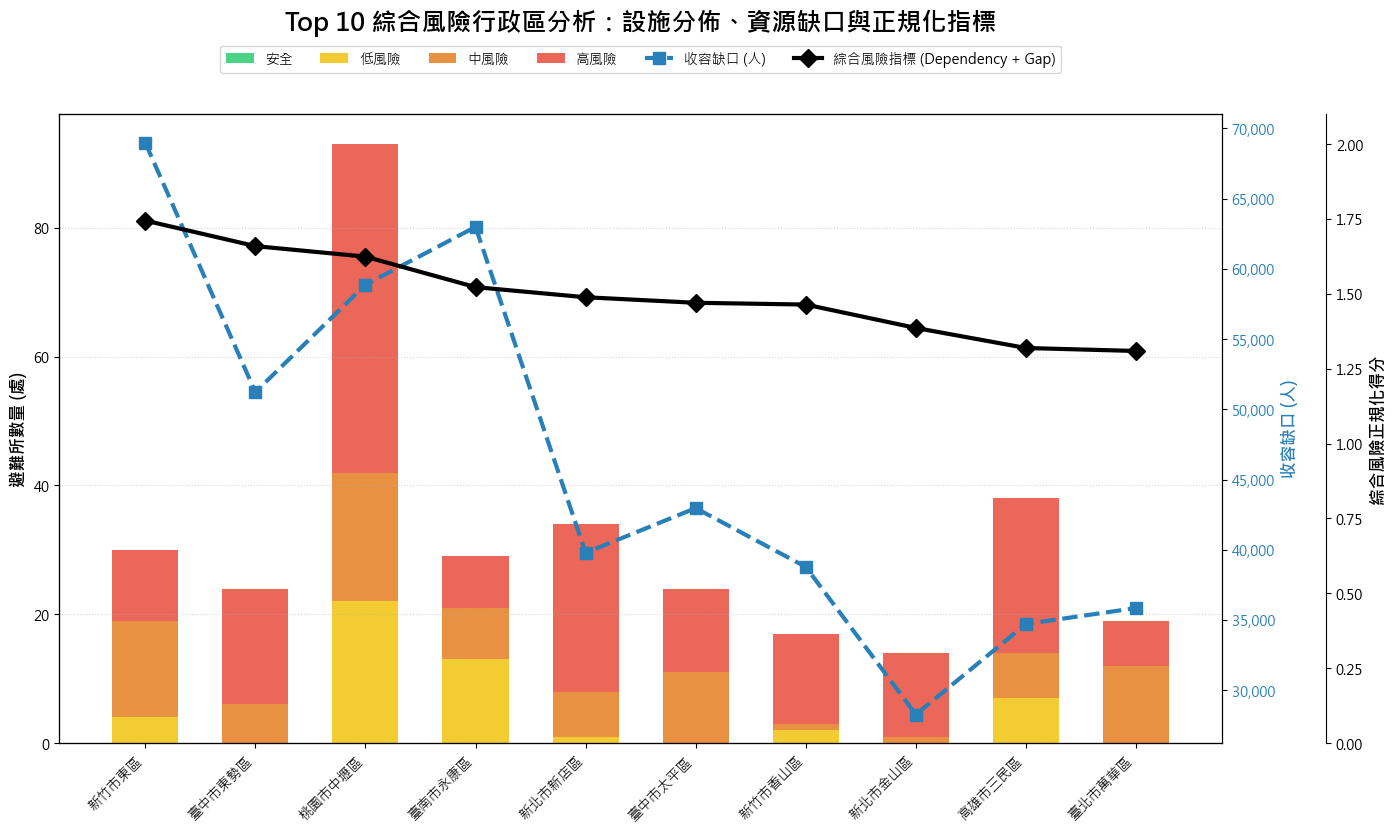

In [ ]:
# STEP 5-2: ADVANCED TRIPLE-AXIS RISK CHART (LAYOUT OPTIMIZED)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

print("=" * 60)
print("STEP 5-2: STATIC STATISTICAL CHART (STACKED BARS + DUAL LINES)")
print("=" * 60)

# 1. 設置字體 (解決中文亂碼)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang HK', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False 

csv_path = 'outputs/insufficient_capacity_townships.csv'
if os.path.exists(csv_path):
    # 讀取資料並取綜合風險得分前 10 名
    plot_df = pd.read_csv(csv_path, encoding='utf-8-sig').sort_values(by='Total_Risk_Score', ascending=False).head(10)
    
    # 💡 直接抓取第 0 欄作為行政區名稱
    township_names = plot_df.iloc[:, 0] 
    x_pos = range(len(township_names))

    # 2. 建立畫布與三 Y 軸
    fig, ax1 = plt.subplots(figsize=(15, 8.5)) # 稍微增加高度以容納標題排版
    ax2 = ax1.twinx() 
    ax3 = ax1.twinx() 
    
    # 偏移第三軸
    ax3.spines['right'].set_position(('outward', 75)) 

    # --- (A) 左軸：堆疊長條圖 ---
    s_c, l_c, m_c, h_c = plot_df['Safe_Count'], plot_df['Low_Count'], plot_df['Med_Count'], plot_df['High_Count']
    
    ax1.bar(x_pos, s_c, color='#2ecc71', label='安全', width=0.6, alpha=0.85)
    ax1.bar(x_pos, l_c, bottom=s_c, color='#f1c40f', label='低風險', width=0.6, alpha=0.85)
    ax1.bar(x_pos, m_c, bottom=s_c+l_c, color='#e67e22', label='中風險', width=0.6, alpha=0.85)
    ax1.bar(x_pos, h_c, bottom=s_c+l_c+m_c, color='#e74c3c', label='高風險', width=0.6, alpha=0.85)

    ax1.set_ylabel('避難所數量 (處)', fontsize=12, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(township_names, rotation=45, ha='right')

    # --- (B) 右軸 1：折線圖 (收容缺口) ---
    ax2.plot(x_pos, plot_df['Cap_Gap'], color='#2980b9', marker='s', markersize=8, 
             linewidth=3, label='收容缺口 (人)', linestyle='--')
    ax2.set_ylabel('收容缺口 (人)', fontsize=12, color='#2980b9', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#2980b9')
    ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # --- (C) 右軸 2：折線圖 (綜合風險指標) ---
    ax3.plot(x_pos, plot_df['Total_Risk_Score'], color='black', marker='D', markersize=9, 
             linewidth=3, label='綜合風險指標 (Dependency + Gap)')
    ax3.set_ylabel('綜合風險正規化得分', fontsize=12, color='black', fontweight='bold')
    ax3.set_ylim(0, 2.1)

    # 3. 圖例與標題排版優化
    h1, lb1 = ax1.get_legend_handles_labels()
    h2, lb2 = ax2.get_legend_handles_labels()
    h3, lb3 = ax3.get_legend_handles_labels()
    
    # 將圖例位置稍稍下移，並讓出空間給標題
    ax1.legend(h1 + h2 + h3, lb1 + lb2 + lb3, loc='upper center', 
               bbox_to_anchor=(0.5, 1.12), ncol=6, fontsize=10, frameon=True)

    # 增加標題的 pad 並設定圖表上邊界
    plt.title('Top 10 綜合風險行政區分析：設施分佈、資源缺口與正規化指標', 
              fontsize=18, fontweight='bold', pad=60)
    
    ax1.grid(axis='y', linestyle=':', alpha=0.5)
    
    # 💡 關鍵排版修正：手動調整子圖上方的留白比例
    fig.subplots_adjust(top=0.85)
    
    # 5. 存檔與顯示
    plt.savefig('outputs/risk_map.png', dpi=300, bbox_inches='tight')
    print(f"✓ 整合型風險統計圖已優化排版並儲存至: outputs/risk_map.png")
    plt.show()

else:
    print(f"❌ 錯誤：找不到 CSV 檔案。")

## STEP 6 特定城市風險計算

在.env中設定TARGET_COUNTY，繪製該縣市中鄉鎮市區之避難所風險長條圖

註：在此以台北市為例

STEP 6: REGIONAL RISK AUDIT - CUSTOM COUNTY


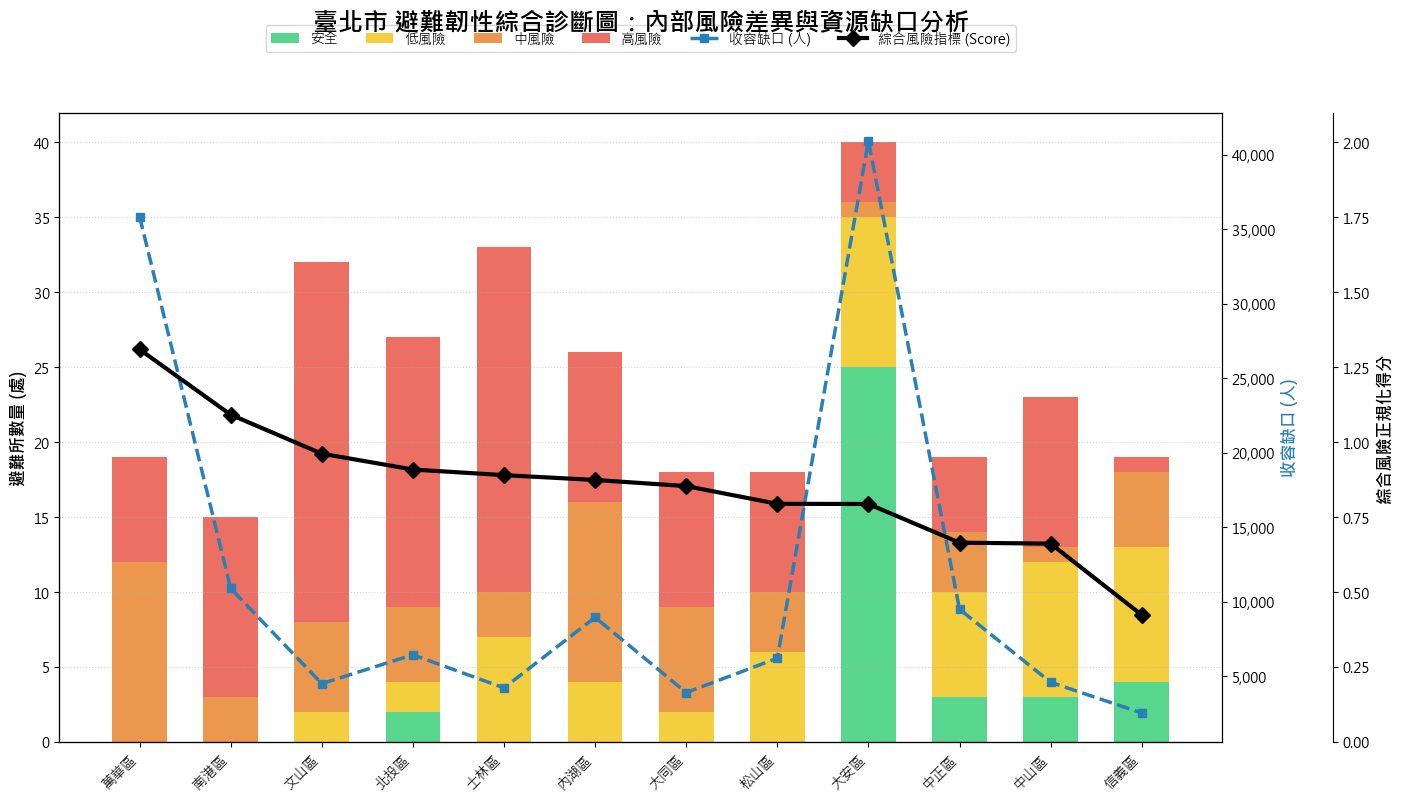

✓ 臺北市 全域審計圖表已儲存至: outputs/risk_audit_臺北市.png


In [12]:
# STEP 6: TARGET COUNTY FULL AUDIT (BULLETPROOF VERSION)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os

print("=" * 60)
print("STEP 6: REGIONAL RISK AUDIT - CUSTOM COUNTY")
print("=" * 60)

# 1. 設定目標縣市 (請確保名稱含「市」或「縣」)
TARGET_COUNTY = '台北市' 
if TARGET_COUNTY.startswith('台'):
    TARGET_COUNTY = TARGET_COUNTY.replace('台', '臺')

# 2. 獲取資料 (嘗試從記憶體或 CSV 讀取)
csv_path = 'outputs/insufficient_capacity_townships.csv'

try:
    # 優先嘗試從記憶體讀取 (township_stats)
    if 'township_stats' in locals():
        source_df = township_stats.reset_index()
        # 確保第一欄名稱統一
        source_df.rename(columns={source_df.columns[0]: '行政區'}, inplace=True)
    else:
        # 如果變數不存在，從 CSV 讀取
        print(f"💡 記憶體中找不到變數，正在從 {csv_path} 載入資料...")
        source_df = pd.read_csv(csv_path, encoding='utf-8-sig')
    
    # 篩選該縣市的行政區
    county_data = source_df[source_df['行政區'].str.startswith(TARGET_COUNTY)].copy()
    
    if len(county_data) == 0:
        print(f"❌ 警告：在資料中找不到 '{TARGET_COUNTY}'，請確認名稱是否正確。")
    else:
        # 依綜合得分排序
        county_data = county_data.sort_values(by='Total_Risk_Score', ascending=False)
        
        # 標籤優化：移除縣市前綴 (如 "臺北市大安區" -> "大安區")
        township_labels = [name.replace(TARGET_COUNTY, '') for name in county_data['行政區']]
        x_pos = range(len(township_labels))

        # 3. 繪製三 Y 軸畫布
        fig, ax1 = plt.subplots(figsize=(15, 8.5))
        ax2 = ax1.twinx() 
        ax3 = ax1.twinx() 
        ax3.spines['right'].set_position(('outward', 80))

        # (A) 左軸：堆疊長條圖
        s_c, l_c, m_c, h_c = county_data['Safe_Count'], county_data['Low_Count'], county_data['Med_Count'], county_data['High_Count']
        ax1.bar(x_pos, s_c, color='#2ecc71', label='安全', width=0.6, alpha=0.8)
        ax1.bar(x_pos, l_c, bottom=s_c, color='#f1c40f', label='低風險', width=0.6, alpha=0.8)
        ax1.bar(x_pos, m_c, bottom=s_c+l_c, color='#e67e22', label='中風險', width=0.6, alpha=0.8)
        ax1.bar(x_pos, h_c, bottom=s_c+l_c+m_c, color='#e74c3c', label='高風險', width=0.6, alpha=0.8)

        ax1.set_ylabel('避難所數量 (處)', fontsize=12, fontweight='bold')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(township_labels, rotation=45, ha='right')

        # (B) 右軸 1：收容缺口 (人)
        ax2.plot(x_pos, county_data['Cap_Gap'], color='#2980b9', marker='s', markersize=6, 
                 linewidth=2.5, label='收容缺口 (人)', linestyle='--')
        ax2.set_ylabel('收容缺口 (人)', fontsize=12, color='#2980b9', fontweight='bold')
        ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

        # (C) 右軸 2：綜合風險得分 (Score)
        ax3.plot(x_pos, county_data['Total_Risk_Score'], color='black', marker='D', markersize=8, 
                 linewidth=3, label='綜合風險指標 (Score)')
        ax3.set_ylabel('綜合風險正規化得分', fontsize=12, color='black', fontweight='bold')
        ax3.set_ylim(0, 2.1)

        # 4. 圖例與標題修正
        h1, lb1 = ax1.get_legend_handles_labels()
        h2, lb2 = ax2.get_legend_handles_labels()
        h3, lb3 = ax3.get_legend_handles_labels()
        ax1.legend(h1 + h2 + h3, lb1 + lb2 + lb3, loc='upper center', 
                   bbox_to_anchor=(0.5, 1.15), ncol=6, fontsize=10)

        plt.title(f'{TARGET_COUNTY} 避難韌性綜合診斷圖：內部風險差異與資源缺口分析', 
                  fontsize=18, fontweight='bold', pad=60)
        ax1.grid(axis='y', linestyle=':', alpha=0.5)
        
        fig.subplots_adjust(top=0.85)
        
        # 5. 存檔與顯示
        save_path = f'outputs/risk_audit_{TARGET_COUNTY}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ {TARGET_COUNTY} 全域審計圖表已儲存至: {save_path}")

except Exception as e:
    print(f"❌ 發生錯誤：{e}")
    print("請先確認 Step 4-2 是否成功執行並產出 CSV 檔案。")